In [5]:
import pandas as pd 
import numpy as np


### Project Introduction 
Customer churn is when a customer stops using a company's product or services and leave for a company competitor. 
Churn is important because losing customers  means losing revenue.
It is usually more expensive to acquire a new customer than  to retain the existing one.
The goal is to build  a Machine Learning classification model that  predicts whether  a customer is likely to churn or stay.

**How could predicting churn help the company
The predicting churn helps the company identify at-risk customer early.
This allows a company to take proactive actions like offers better services to retain them and reduce revenue loss.

In [6]:
import os
print(os.getcwd())

C:\Users\abc


In [7]:
os.chdir("C:\\Users\\abc\\Desktop\\crop prod & yield")

In [8]:
df = pd.read_csv("customer_churn_prediction_dataset.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0296-XXXX,Female,1,No,Yes,61,No,Yes,DSL,No,...,Yes,No internet service,No,No,One year,Yes,Electronic check,42.52,2593.72,No
296,0297-XXXX,Female,0,No,No,49,Yes,No phone service,DSL,No internet service,...,Yes,No internet service,Yes,Yes,Month-to-month,Yes,Mailed check,22.31,1093.19,Yes
297,0298-XXXX,Male,0,No,Yes,71,Yes,Yes,DSL,No internet service,...,Yes,Yes,No,Yes,Two year,No,Mailed check,59.57,4229.47,Yes
298,0299-XXXX,Male,1,Yes,Yes,1,Yes,Yes,No,Yes,...,No internet service,No internet service,Yes,Yes,Two year,No,Credit card,31.32,31.32,No


In [9]:
type(df)

pandas.core.frame.DataFrame

In [10]:
#checking for missing values
df[df.isna().any(axis=1)]
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df = pd.read_csv(
    "customer_churn_prediction_dataset.csv",
    na_values=" "
)

df


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0296-XXXX,Female,1,No,Yes,61,No,Yes,DSL,No,...,Yes,No internet service,No,No,One year,Yes,Electronic check,42.52,2593.72,No
296,0297-XXXX,Female,0,No,No,49,Yes,No phone service,DSL,No internet service,...,Yes,No internet service,Yes,Yes,Month-to-month,Yes,Mailed check,22.31,1093.19,Yes
297,0298-XXXX,Male,0,No,Yes,71,Yes,Yes,DSL,No internet service,...,Yes,Yes,No,Yes,Two year,No,Mailed check,59.57,4229.47,Yes
298,0299-XXXX,Male,1,Yes,Yes,1,Yes,Yes,No,Yes,...,No internet service,No internet service,Yes,Yes,Two year,No,Credit card,31.32,31.32,No


In [12]:
#checking for the structure to make ready for EDA
df.head()
df.shape
df.columns
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [13]:
#rechecking for missing values
df.isna().sum()
#duplicates
df.duplicated().sum()


np.int64(0)

In [14]:
#converting four  variables of Yes/No into  int64
yes_no_cols = ["Churn","Partner","PaperlessBilling","PhoneService"]
for col in yes_no_cols:
    df[col] = df[col].map({"Yes":1,"No":0})

In [15]:
#checking for yes/no if its 0s and 1s
df[yes_no_cols + ["SeniorCitizen"]].head()  

,Churn,Partner,PaperlessBilling,PhoneService,SeniorCitizen
0,1,1,1,0,0
1,1,0,0,1,0
2,1,0,0,1,0
3,0,0,0,1,1
4,1,1,0,0,1


In [16]:
#rechecking 
df.head()
df.shape
df.columns
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner               int64
Dependents           object
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        300 non-null    object 
 1   gender            300 non-null    object 
 2   SeniorCitizen     300 non-null    int64  
 3   Partner           300 non-null    int64  
 4   Dependents        300 non-null    object 
 5   tenure            300 non-null    int64  
 6   PhoneService      300 non-null    int64  
 7   MultipleLines     300 non-null    object 
 8   InternetService   300 non-null    object 
 9   OnlineSecurity    300 non-null    object 
 10  OnlineBackup      300 non-null    object 
 11  DeviceProtection  300 non-null    object 
 12  TechSupport       300 non-null    object 
 13  StreamingTV       300 non-null    object 
 14  StreamingMovies   300 non-null    object 
 15  Contract          300 non-null    object 
 16  PaperlessBilling  300 non-null    int64  
 1

In [18]:
yes_no_cols = ["Dependents","MultipleLines"]
for col in yes_no_cols:
    df[col] = df[col].map({"Yes":1,"No":0,"No phone service":0})
    

In [19]:
df[yes_no_cols]
df



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,1,1,5,0,1,No,No,...,No,No,No,No internet service,Month-to-month,1,Credit card,27.43,137.15,1
1,0002-XXXX,Female,0,0,0,42,1,0,DSL,Yes,...,No,No,No internet service,No internet service,Two year,0,Electronic check,38.28,1607.76,1
2,0003-XXXX,Male,0,0,0,61,1,0,No,No,...,No,Yes,Yes,No,One year,0,Bank transfer,106.44,6492.84,1
3,0004-XXXX,Male,1,0,1,22,1,0,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,0,Electronic check,92.49,2034.78,0
4,0005-XXXX,Male,1,1,1,21,0,0,DSL,No,...,No internet service,No,No,No internet service,One year,0,Bank transfer,19.63,412.23,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0296-XXXX,Female,1,0,1,61,0,1,DSL,No,...,Yes,No internet service,No,No,One year,1,Electronic check,42.52,2593.72,0
296,0297-XXXX,Female,0,0,0,49,1,0,DSL,No internet service,...,Yes,No internet service,Yes,Yes,Month-to-month,1,Mailed check,22.31,1093.19,1
297,0298-XXXX,Male,0,0,1,71,1,1,DSL,No internet service,...,Yes,Yes,No,Yes,Two year,0,Mailed check,59.57,4229.47,1
298,0299-XXXX,Male,1,1,1,1,1,1,No,Yes,...,No internet service,No internet service,Yes,Yes,Two year,0,Credit card,31.32,31.32,0


In [20]:
yes_no_cols = ["OnlineSecurity","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
for col in yes_no_cols:
    df[col] = df[col].map({"Yes":1,"No":0,"No internet service":0})

In [21]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,1,1,5,0,1,No,0,...,0,0,0,0,Month-to-month,1,Credit card,27.43,137.15,1
1,0002-XXXX,Female,0,0,0,42,1,0,DSL,1,...,0,0,0,0,Two year,0,Electronic check,38.28,1607.76,1
2,0003-XXXX,Male,0,0,0,61,1,0,No,0,...,0,1,1,0,One year,0,Bank transfer,106.44,6492.84,1
3,0004-XXXX,Male,1,0,1,22,1,0,No,0,...,1,0,0,1,Month-to-month,0,Electronic check,92.49,2034.78,0
4,0005-XXXX,Male,1,1,1,21,0,0,DSL,0,...,0,0,0,0,One year,0,Bank transfer,19.63,412.23,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0296-XXXX,Female,1,0,1,61,0,1,DSL,0,...,1,0,0,0,One year,1,Electronic check,42.52,2593.72,0
296,0297-XXXX,Female,0,0,0,49,1,0,DSL,0,...,1,0,1,1,Month-to-month,1,Mailed check,22.31,1093.19,1
297,0298-XXXX,Male,0,0,1,71,1,1,DSL,0,...,1,1,0,1,Two year,0,Mailed check,59.57,4229.47,1
298,0299-XXXX,Male,1,1,1,1,1,1,No,1,...,0,0,1,1,Two year,0,Credit card,31.32,31.32,0


In [22]:
#text to dummy columns
df = pd.get_dummies(df, columns=["gender","InternetService","Contract","PaymentMethod"],drop_first=True)

In [23]:
df

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,TotalCharges,Churn,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0001-XXXX,0,1,1,5,0,1,0,Yes,0,...,137.15,1,True,False,True,False,False,True,False,False
1,0002-XXXX,0,0,0,42,1,0,1,Yes,0,...,1607.76,1,False,False,False,False,True,False,True,False
2,0003-XXXX,0,0,0,61,1,0,0,Yes,0,...,6492.84,1,True,False,True,True,False,False,False,False
3,0004-XXXX,1,0,1,22,1,0,0,No internet service,1,...,2034.78,0,True,False,True,False,False,False,True,False
4,0005-XXXX,1,1,1,21,0,0,0,No,0,...,412.23,1,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0296-XXXX,1,0,1,61,0,1,0,No internet service,1,...,2593.72,0,False,False,False,True,False,False,True,False
296,0297-XXXX,0,0,0,49,1,0,0,No,1,...,1093.19,1,False,False,False,False,False,False,False,True
297,0298-XXXX,0,0,1,71,1,1,0,No,1,...,4229.47,1,True,False,False,False,True,False,False,True
298,0299-XXXX,1,1,1,1,1,1,1,No internet service,0,...,31.32,0,True,False,True,False,True,True,False,False


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customerID                      300 non-null    object 
 1   SeniorCitizen                   300 non-null    int64  
 2   Partner                         300 non-null    int64  
 3   Dependents                      300 non-null    int64  
 4   tenure                          300 non-null    int64  
 5   PhoneService                    300 non-null    int64  
 6   MultipleLines                   300 non-null    int64  
 7   OnlineSecurity                  300 non-null    int64  
 8   OnlineBackup                    300 non-null    object 
 9   DeviceProtection                300 non-null    int64  
 10  TechSupport                     300 non-null    int64  
 11  StreamingTV                     300 non-null    int64  
 12  StreamingMovies                 300 

In [25]:
df["OnlineBackup"].map({"Yes":1,"No":0,"No internet service":0})
#dropping customerID
df = df.drop("customerID",axis=1)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   SeniorCitizen                   300 non-null    int64  
 1   Partner                         300 non-null    int64  
 2   Dependents                      300 non-null    int64  
 3   tenure                          300 non-null    int64  
 4   PhoneService                    300 non-null    int64  
 5   MultipleLines                   300 non-null    int64  
 6   OnlineSecurity                  300 non-null    int64  
 7   OnlineBackup                    300 non-null    object 
 8   DeviceProtection                300 non-null    int64  
 9   TechSupport                     300 non-null    int64  
 10  StreamingTV                     300 non-null    int64  
 11  StreamingMovies                 300 non-null    int64  
 12  PaperlessBilling                300 

In [27]:
df["OnlineBackup"].map({"Yes":1,"No":0,"No internet service":0})

0      1
1      1
2      1
3      0
4      0
      ..
295    0
296    0
297    0
298    0
299    0
Name: OnlineBackup, Length: 300, dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   SeniorCitizen                   300 non-null    int64  
 1   Partner                         300 non-null    int64  
 2   Dependents                      300 non-null    int64  
 3   tenure                          300 non-null    int64  
 4   PhoneService                    300 non-null    int64  
 5   MultipleLines                   300 non-null    int64  
 6   OnlineSecurity                  300 non-null    int64  
 7   OnlineBackup                    300 non-null    object 
 8   DeviceProtection                300 non-null    int64  
 9   TechSupport                     300 non-null    int64  
 10  StreamingTV                     300 non-null    int64  
 11  StreamingMovies                 300 non-null    int64  
 12  PaperlessBilling                300 

In [29]:
yes_no_cols = ["OnlineBackup"]
for col in yes_no_cols:
    df[col] = df[col].map({"Yes":1,"No":0,"No internet service":0})

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   SeniorCitizen                   300 non-null    int64  
 1   Partner                         300 non-null    int64  
 2   Dependents                      300 non-null    int64  
 3   tenure                          300 non-null    int64  
 4   PhoneService                    300 non-null    int64  
 5   MultipleLines                   300 non-null    int64  
 6   OnlineSecurity                  300 non-null    int64  
 7   OnlineBackup                    300 non-null    int64  
 8   DeviceProtection                300 non-null    int64  
 9   TechSupport                     300 non-null    int64  
 10  StreamingTV                     300 non-null    int64  
 11  StreamingMovies                 300 non-null    int64  
 12  PaperlessBilling                300 

In [31]:
df.isnull().sum()

SeniorCitizen                     0
Partner                           0
Dependents                        0
tenure                            0
PhoneService                      0
MultipleLines                     0
OnlineSecurity                    0
OnlineBackup                      0
DeviceProtection                  0
TechSupport                       0
StreamingTV                       0
StreamingMovies                   0
PaperlessBilling                  0
MonthlyCharges                    0
TotalCharges                      0
Churn                             0
gender_Male                       0
InternetService_Fiber optic       0
InternetService_No                0
Contract_One year                 0
Contract_Two year                 0
PaymentMethod_Credit card         0
PaymentMethod_Electronic check    0
PaymentMethod_Mailed check        0
dtype: int64

In [32]:
#counting how many customers stayed vs how many customers left
df["Churn"].value_counts()

Churn
0    161
1    139
Name: count, dtype: int64

In [33]:
#giving percentage instead of raw counts
df["Churn"].value_counts(normalize=True) * 100

Churn
0    53.666667
1    46.333333
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

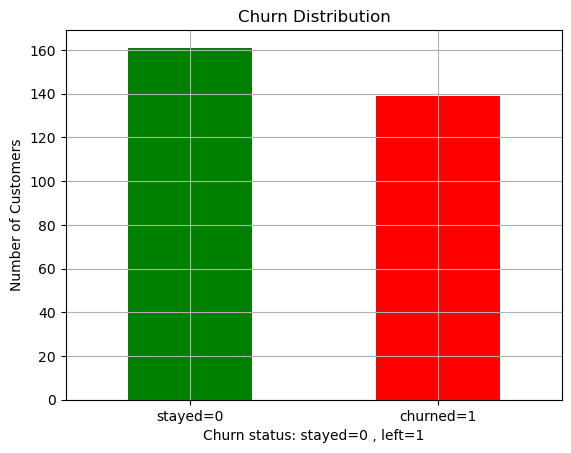

In [34]:
import matplotlib.pyplot as plt
df["Churn"].value_counts().plot(kind="bar",color=["green","red"])
plt.title("Churn Distribution")
plt.xlabel("Churn status: stayed=0 , left=1")
plt.ylabel("Number of Customers")
plt.xticks([0,1], ["stayed=0","churned=1"],rotation=0) 
plt.grid()
plt.show

### Target Variable Distribution Analysis
54% of customers stayed(churn=0)
46% of customers left(churn=1)
The dataset is fairly balanced with only 8% difference.
Since the classes are almost 50/50 when rounding off , the  model should not have major bia issues.    


In [35]:
df

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,TotalCharges,Churn,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,1,5,0,1,0,1,0,0,...,137.15,1,True,False,True,False,False,True,False,False
1,0,0,0,42,1,0,1,1,0,0,...,1607.76,1,False,False,False,False,True,False,True,False
2,0,0,0,61,1,0,0,1,0,1,...,6492.84,1,True,False,True,True,False,False,False,False
3,1,0,1,22,1,0,0,0,1,0,...,2034.78,0,True,False,True,False,False,False,True,False
4,1,1,1,21,0,0,0,0,0,0,...,412.23,1,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1,0,1,61,0,1,0,0,1,0,...,2593.72,0,False,False,False,True,False,False,True,False
296,0,0,0,49,1,0,0,0,1,0,...,1093.19,1,False,False,False,False,False,False,False,True
297,0,0,1,71,1,1,0,0,1,1,...,4229.47,1,True,False,False,False,True,False,False,True
298,1,1,1,1,1,1,1,0,0,0,...,31.32,0,True,False,True,False,True,True,False,False


In [36]:
print(df.shape)
df.head()
df.columns.tolist()
df.info()

(300, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   SeniorCitizen                   300 non-null    int64  
 1   Partner                         300 non-null    int64  
 2   Dependents                      300 non-null    int64  
 3   tenure                          300 non-null    int64  
 4   PhoneService                    300 non-null    int64  
 5   MultipleLines                   300 non-null    int64  
 6   OnlineSecurity                  300 non-null    int64  
 7   OnlineBackup                    300 non-null    int64  
 8   DeviceProtection                300 non-null    int64  
 9   TechSupport                     300 non-null    int64  
 10  StreamingTV                     300 non-null    int64  
 11  StreamingMovies                 300 non-null    int64  
 12  PaperlessBilling          

In [37]:
#Testing for independancy (Association or relationship) between target variable and strong predictor variables usig contingency table
df.columns.tolist()

['SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'gender_Male',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [38]:
df_original = pd.read_csv("customer_churn_prediction_dataset.csv")
df_original

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0296-XXXX,Female,1,No,Yes,61,No,Yes,DSL,No,...,Yes,No internet service,No,No,One year,Yes,Electronic check,42.52,2593.72,No
296,0297-XXXX,Female,0,No,No,49,Yes,No phone service,DSL,No internet service,...,Yes,No internet service,Yes,Yes,Month-to-month,Yes,Mailed check,22.31,1093.19,Yes
297,0298-XXXX,Male,0,No,Yes,71,Yes,Yes,DSL,No internet service,...,Yes,Yes,No,Yes,Two year,No,Mailed check,59.57,4229.47,Yes
298,0299-XXXX,Male,1,Yes,Yes,1,Yes,Yes,No,Yes,...,No internet service,No internet service,Yes,Yes,Two year,No,Credit card,31.32,31.32,No


In [39]:
import seaborn as sns
print(df_original.describe())
print(df_original["Churn"].value_counts())

       SeniorCitizen      tenure  MonthlyCharges  TotalCharges
count     300.000000  300.000000      300.000000    300.000000
mean        0.543333   35.783333       67.226800   2477.975767
std         0.498951   21.113400       28.638073   1918.540111
min         0.000000    1.000000       18.450000     30.030000
25%         0.000000   17.000000       42.337500    910.302500
50%         1.000000   36.000000       68.635000   2072.400000
75%         1.000000   53.250000       92.430000   3618.405000
max         1.000000   72.000000      118.640000   8318.880000
Churn
No     161
Yes    139
Name: count, dtype: int64


Text(0.5, 1.0, 'Churn Count')

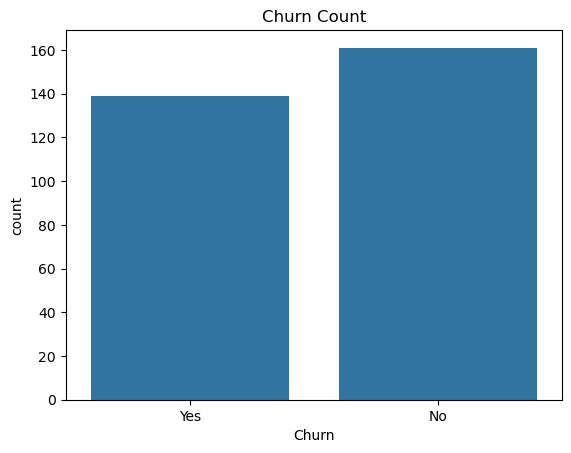

In [40]:
plt.figure()
sns.countplot(x="Churn", data = df_original)
plt.title("Churn Count")

In [41]:
pd.crosstab(df_original["Contract"], df_original["Churn"], normalize="index")*100

Churn,No,Yes
Contract,,
Month-to-month,51.351351,48.648649
One year,53.608247,46.391753
Two year,56.521739,43.478261


<Axes: xlabel='tenure', ylabel='Count'>

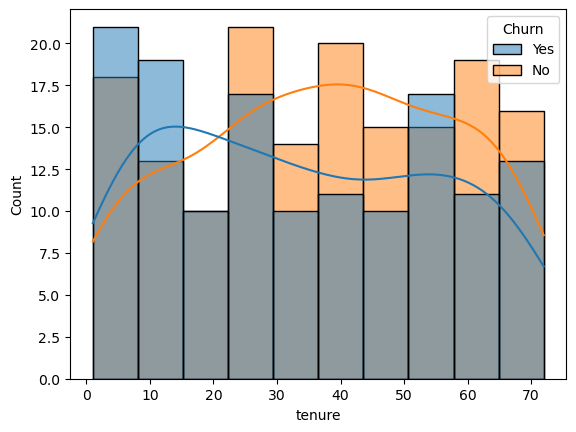

In [42]:
plt.figure()
sns.histplot(data=df_original, x="tenure", hue="Churn",kde=True)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

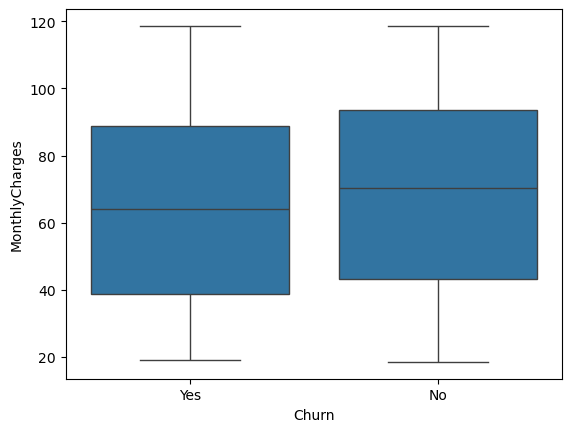

In [43]:
plt.figure()
sns.boxplot(x="Churn", y="MonthlyCharges", data = df_original)

<Axes: xlabel='Contract', ylabel='count'>

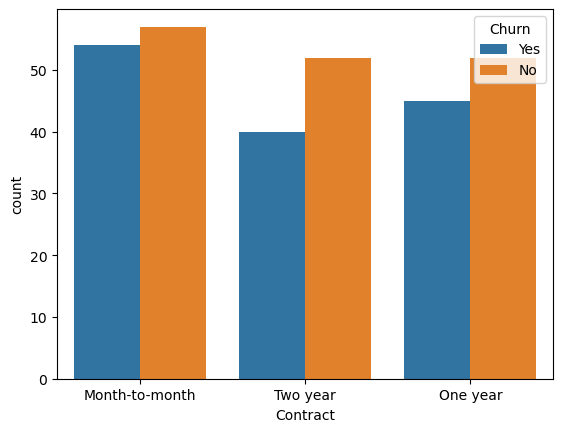

In [44]:
sns.countplot(x="Contract", hue ="Churn", data=df_original)



In [45]:
pd.crosstab(df_original["Contract"], df_original["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.513514,0.486486
One year,0.536082,0.463918
Two year,0.565217,0.434783


In [46]:
contingency = pd.crosstab(df_original["Contract"],df_original["Churn"])
contingency 

Churn,No,Yes
Contract,,
Month-to-month,57,54
One year,52,45
Two year,52,40


H0: There is independance between Churn and Contract(no relationship)
Hi:There is dependance between Churn and Contract(relationship)

In [47]:
#Running the full chi square test
from scipy.stats import chi2_contingency
con_table = pd.crosstab(df_original["Contract"], df_original["Churn"])
chi2 , p , dof, exp = chi2_contingency(con_table)
print(f"Contract vs Churn p-value: {p}")
print(f"Chi2 statistics: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contract vs Churn p-value: 0.7629867169524656
Chi2 statistics: 0.5410
Degrees of freedom: 2
p-value: 0.7630


{Chi2>5.9915,df=2,alpha=0.05}(reject)
Therefore we fail to reject the null hypothesis and p-value=0.7630 which emphasizes that Churn and Contract is not statistically significant
hence there is no relationship between Contract and Churn 

In [48]:
#After findng out my previous dataset n=300 rows and I coundn't get clear  relationship betweeen features and target variable I found out that  I downloaded dataset with cut info hence found the following dataset


df2 = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df2

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [49]:
type(df2)

pandas.core.frame.DataFrame

In [50]:
#checking for missing values
df2[df2.isna().any(axis=1)]
df2.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [51]:
#duplicates
df2.duplicated().sum()


np.int64(0)

In [52]:
#checking for the structure to make ready for EDA
df2.head()
df2.shape
df2.columns
df2.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [53]:
yes_no_cols = ["OnlineSecurity","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Dependents","MultipleLines","OnlineBackup"]
for col in yes_no_cols:
    df2[col] = df2[col].map({"Yes":1,"No":0,"No internet service":0,"No phone service":0})

In [54]:
#checking for yes/no if its 0s and 1s
df2[yes_no_cols + ["SeniorCitizen"]].head() 

,OnlineSecurity,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Dependents,MultipleLines,OnlineBackup,SeniorCitizen
0,0,0,0,0,0,0,0,1,0
1,1,1,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,1,0
3,1,1,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0


In [55]:
yes_no_cols = ["Churn","Partner","PaperlessBilling","PhoneService"]
for col in yes_no_cols:
    df2[col] = df2[col].map({"Yes":1,"No":0})

In [56]:
df2

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,1,1,24,1,1,DSL,1,...,1,1,1,1,One year,1,Mailed check,84.80,1990.5,0
7039,2234-XADUH,Female,0,1,1,72,1,1,Fiber optic,0,...,1,0,1,1,One year,1,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,Female,0,1,1,11,0,0,DSL,1,...,0,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,1,0,4,1,1,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Mailed check,74.40,306.6,1


In [57]:
df2_original = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df2_original

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [58]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


In [59]:
df2["TotalCharges"] = df2["TotalCharges"].astype(str).str.strip()
df2["TotalCharges"] = pd.to_numeric(df2["TotalCharges"], errors="coerce")
print("NaN count:", df2["TotalCharges"].isna().sum())
df2["TotalCharges"] = df2["TotalCharges"].fillna(0)

NaN count: 11


In [60]:
df2_original["TotalCharges"] = pd.to_numeric(df2_original["TotalCharges"].astype(str).str.strip(), errors="coerce")
df2_original["TotalCharges"] = df2_original["TotalCharges"].fillna(0)

<function matplotlib.pyplot.show(close=None, block=None)>

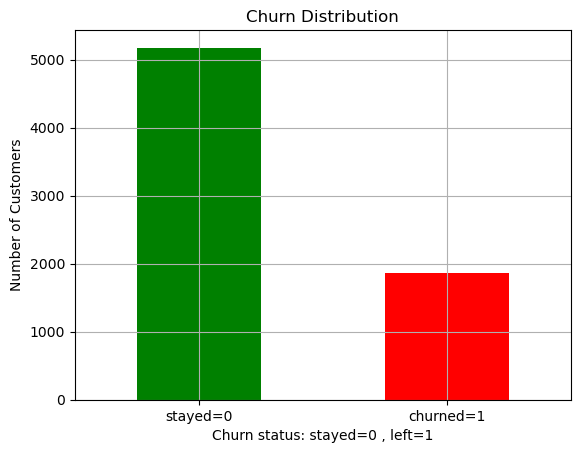

In [61]:
df2["Churn"].value_counts().plot(kind="bar",color=["green","red"])
plt.title("Churn Distribution")
plt.xlabel("Churn status: stayed=0 , left=1")
plt.ylabel("Number of Customers")
plt.xticks([0,1], ["stayed=0","churned=1"],rotation=0) 
plt.grid()
plt.show

In [62]:
df2["Churn"].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

73% of customers stayed(churn=0) 27% of customers left(churn=1) The dataset is slightly imbalanced.
There are almost 3 times more customers who stayed than those who left.
This could lead to predictions in favor of "no churn"

In [63]:
print(df2_original.describe())
print(df2_original["Churn"].value_counts())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2279.734304
std         0.368612    24.559481       30.090047   2266.794470
min         0.000000     0.000000       18.250000      0.000000
25%         0.000000     9.000000       35.500000    398.550000
50%         0.000000    29.000000       70.350000   1394.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000
Churn
No     5174
Yes    1869
Name: count, dtype: int64


Text(0.5, 1.0, 'Churn Count')

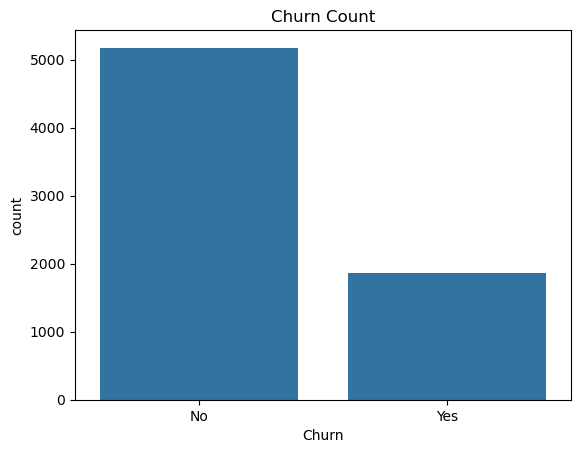

In [64]:
#EDA
plt.figure()
sns.countplot(x="Churn", data = df2_original)
plt.title("Churn Count")

countplot shows that there 500+ customers who stayed  and slightly less than 2000 customers left

<Axes: xlabel='tenure', ylabel='Count'>

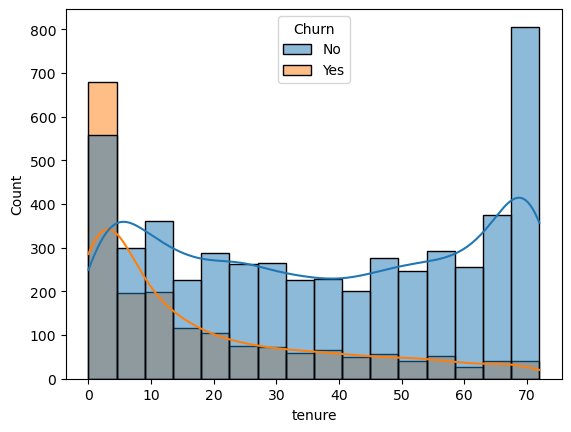

In [65]:
plt.figure()
sns.histplot(data=df2_original, x="tenure", hue="Churn",kde=True)

At the start of the tenure customers are likely to churn(leave).
But also we witness long term customers 70 are highly and likely to stay loyal.
As for tenure between 10 and 60 significe that once customers pass few months  they are also likely to stay around.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

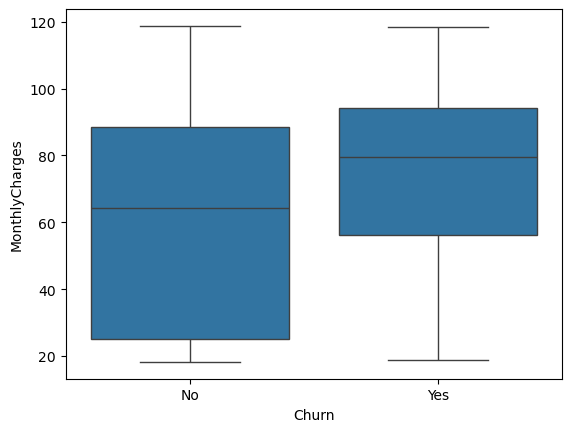

In [66]:
plt.figure()
sns.boxplot(x="Churn", y="MonthlyCharges", data = df2_original)

<Axes: xlabel='Contract', ylabel='count'>

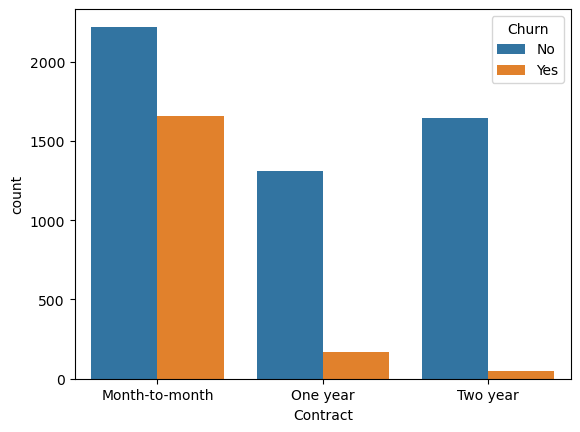

In [67]:
sns.countplot(x="Contract", hue ="Churn", data=df2_original)

The plot shows month-to-month contractors where there's high count of custumers who stayed and Churned,
as for one year contractor there is lower count of customers who churned and 
for two year contractors we have lowest customers who churned also slightly less count of customers who stayed compared to
month-to-month contractors.Hence customers who long term customers are most likely to stay loyal

#Test for independancy (contingency table)


H0: There is independance between Churn and Contract(no relationship)


Hi:There is dependance between Churn and Contract(relationship)


In [68]:
contingency = pd.crosstab(df2_original["Contract"],df2_original["Churn"])
contingency 

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [69]:
con_table = pd.crosstab(df2_original["Contract"], df2_original["Churn"])
chi2 , p , dof, exp = chi2_contingency(con_table)
print(f"Contract vs Churn p-value: {p}")
print(f"Chi2 statistics: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contract vs Churn p-value: 5.863038300673391e-258
Chi2 statistics: 1184.5966
Degrees of freedom: 2
p-value: 0.0000


{Chi2>5.9915,df=2,alpha=0.05}(reject)


Therefore we  reject the null hypothesis and p-value=5.863038300673391e-258 which emphasizes that Churn and Contract is statistically significant
hence there is a relationship between Contract and Churn 

In [70]:
for col in ["PaperlessBilling","PaymentMethod"]:
    table = pd.crosstab(df2_original[col],df2_original["Churn"])
    chi2, p, dof,exp = chi2_contingency(table)
    print(col, f"chi2={chi2:.2f} p={p:.2e} dof={dof}")

PaperlessBilling chi2=258.28 p=4.07e-58 dof=1
PaymentMethod chi2=648.14 p=3.68e-140 dof=3


PaperlessBilling and PaymentMethod are statistically significant p-value=(4.07e-58,3.68e-140) respectively 
Hence there's an evidance that there is relationship between the two variables and Churn

In [71]:
#Encoding ,correlation and heat map
account_df = df2[["Contract","MonthlyCharges","PaperlessBilling","PaymentMethod","TotalCharges","Churn"]].copy()

In [72]:
#Encoding
account_df = pd.get_dummies(account_df, columns=["Contract","PaymentMethod"], drop_first=True)

In [73]:
corr = account_df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)
print(corr)

Churn                                    1.000000
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Contract_One year                       -0.177820
TotalCharges                            -0.198324
Contract_Two year                       -0.302253
Name: Churn, dtype: float64


Account info relevant features:

PaymentMethod_Electronic check(0.3) shows strong positive correlation with churn meaning it increases Churn.
While Contract_Two year(-0.3) is negatively correlated which reduces churn the most followed by TotalCharges(-1.98)
and Contract_One year(-0.1778) which are also negatively correlated



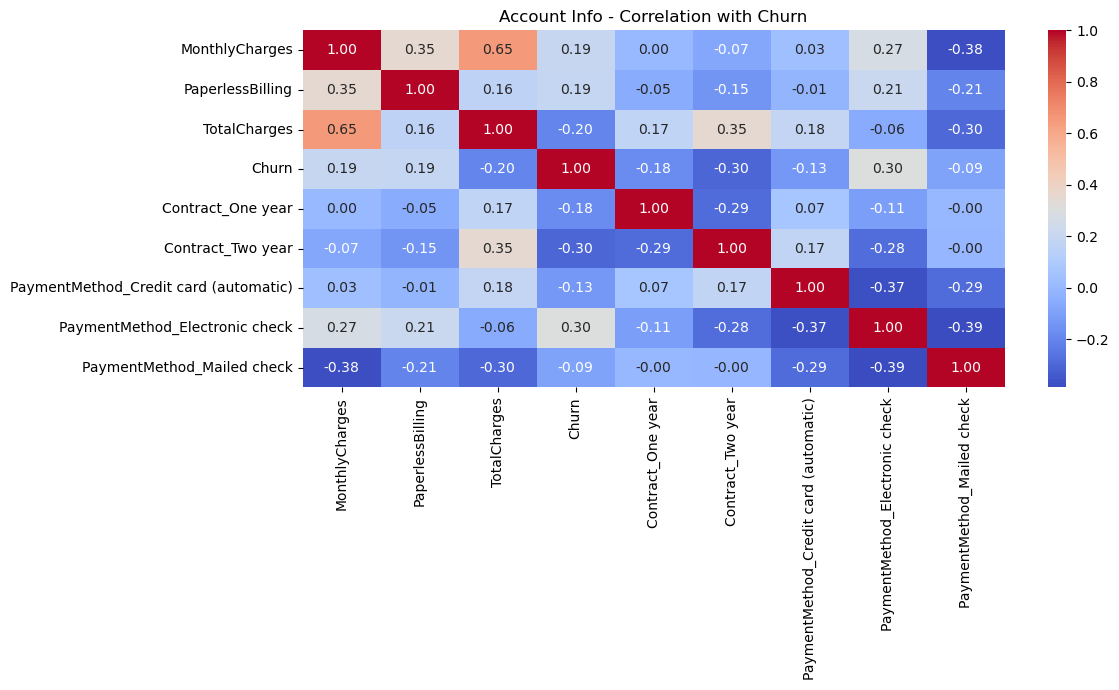

In [74]:
#heatmap
plt.figure(figsize=(12,7))
sns.heatmap(account_df.corr(), annot = True , cmap="coolwarm",fmt=".2f")
plt.title("Account Info - Correlation with Churn")
plt.tight_layout()
plt.show()

In [94]:
cat_cols= df2.select_dtypes(include="object").columns.tolist()
print("To encode:",cat_cols)

To encode: ['gender', 'InternetService', 'Contract', 'PaymentMethod']


In [123]:
df2 = df2.drop('customerID',axis=1)
cat_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod']
df_encoded =pd.get_dummies(df2, columns=cat_cols, drop_first=True)

KeyError: "['customerID'] not found in axis"

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
num_cols =["tenure","MonthlyCharges","TotalCharges"]

In [ ]:
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
df_encoded[num_cols].head()

In [ ]:
#AvgMonthly = TotalCharges /tenure
df2["AvgMonthlyCharge"] = df2["TotalCharges"]/df2["tenure"].replace(0,1)

In [ ]:
from sklearn.model_selection import train_test_split



In [96]:
X = df_encoded.drop("Churn",axis=1)
y = df_encoded["Churn"]
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42 ,
    stratify=y
)
print("Split done:",X_train.shape)

Split done: (5634, 23)


In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,precision_score,recall_score,f1_score,
    confusion_matrix, classification_report, roc_auc_score ,roc_curve
)

In [98]:
#LogisticRegression model as a baseline model
baseline = LogisticRegression(max_iter=1000,random_state=42)
baseline.fit(X_train,y_train)

y_train_pred = baseline.predict(X_train)
y_test_pred = baseline.predict(X_test)
y_test_proba = baseline.predict_proba(X_test)[:,1]

print(f"Accuracy : {accuracy_score(y_test,y_test_pred):.4f}")
print(f"Precision : {precision_score(y_test,y_test_pred):.4f}")
print(f"Recall : {recall_score(y_test,y_test_pred):.4f}")
print(f"F1-Score : {f1_score(y_test,y_test_pred):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test,y_test_proba):.4f}")

print("\nClassification Report:\n", classification_report(y_test,y_test_pred))
print("\nConfusion Matrix:\n" , confusion_matrix(y_test,y_test_pred))

Accuracy : 0.8055
Precision : 0.6582
Recall : 0.5561
F1-Score : 0.6029
ROC-AUC : 0.8423

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
 [[927 108]
 [166 208]]


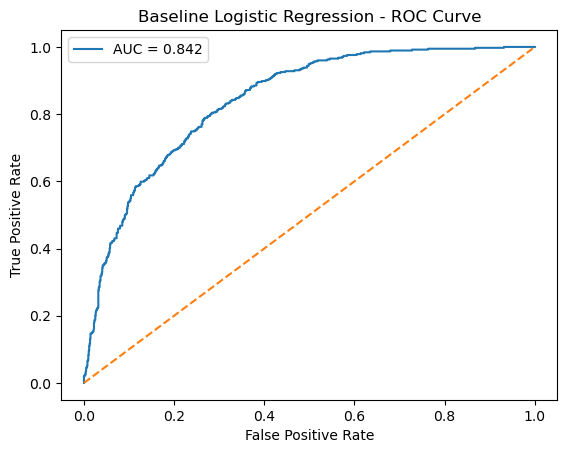

In [85]:
#ROC Curve
fpr, tpr,_ =roc_curve(y_test,y_test_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,y_test_proba):.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline Logistic Regression - ROC Curve")
plt.legend()
plt.show()

In [99]:
from sklearn.tree import DecisionTreeClassifier


In [100]:
for d in [3,4,5,6,7,8,9,10]:
    dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=20,random_state=42)
    dt.fit(X_train,y_train)
    print(d, roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

3 0.8167661267405513
4 0.8284752899842414
5 0.8267922188638301
6 0.826825802784882
7 0.8218463406442946
8 0.8201451858740862
9 0.8144707949055776
10 0.813982536361053


In [88]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20,random_state=42)
dt.fit(X_train,y_train)

y_test_pred_dt = dt.predict(X_test)
y_test_proba_dt = dt.predict_proba(X_test)[:,1]

print(f"DT Accuracy : {accuracy_score(y_test,y_test_pred_dt):.4f}")
print(f"DT F1-Score : {f1_score(y_test,y_test_pred_dt):.4f}")
print(f"DT ROC-AUC : {roc_auc_score(y_test,y_test_proba_dt):.4f}")



DT Accuracy : 0.7999
DT F1-Score : 0.5675
DT ROC-AUC : 0.8268


In [89]:
print("\nClassification Report:\n", classification_report(y_test,y_test_pred_dt))
print("\nConfusion Matrix:\n" , confusion_matrix(y_test,y_test_pred_dt))


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
 [[942  93]
 [189 185]]


In [90]:
importances_dt = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 10 DT Features:\n", importances_dt.head(10))


Top 10 DT Features:
 tenure                            0.399434
InternetService_Fiber optic       0.335090
TotalCharges                      0.051606
InternetService_No                0.035658
PaymentMethod_Electronic check    0.035301
MonthlyCharges                    0.031166
Contract_Two year                 0.025455
MultipleLines                     0.022146
Contract_One year                 0.017617
OnlineSecurity                    0.009232
dtype: float64


In [91]:
from sklearn.ensemble import RandomForestClassifier


In [92]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train,y_train)

y_test_pred_rf = rf.predict(X_test)
y_test_proba_rf = rf.predict_proba(X_test)[:,1]

print(f"RF Accuracy : {accuracy_score(y_test,y_test_pred_rf):.4f}")
print(f"RF F1-Score : {f1_score(y_test,y_test_pred_rf):.4f}")
print(f"RF ROC-AUC : {roc_auc_score(y_test,y_test_proba_rf):.4f}")

RF Accuracy : 0.7842
RF F1-Score : 0.6209
RF ROC-AUC : 0.8397


In [202]:
print("\nClassification Report:\n", classification_report(y_test,y_test_pred_rf))
print("\nConfusion Matrix:\n" , confusion_matrix(y_test,y_test_pred_rf))


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.83      0.85      1035
           1       0.58      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409


Confusion Matrix:
 [[856 179]
 [125 249]]


In [201]:
results = {
    "Model":["Baseline","Decision Tree","Random Forest"],
    "Acuracy": [
        accuracy_score(y_test,y_test_pred),
        accuracy_score(y_test,y_test_pred_dt),
        accuracy_score(y_test,y_test_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test,y_test_pred),
        f1_score(y_test,y_test_pred_dt),
        f1_score(y_test,y_test_pred_rf)
    ],
    "ROC-AUC (proba)" : [
        roc_auc_score(y_test,y_test_proba),
        roc_auc_score(y_test,y_test_proba_dt),
        roc_auc_score(y_test,y_test_proba_rf)
    ]
}

df_compare = pd.DataFrame(results).round(4)
print(df_compare.sort_values("ROC-AUC (proba)", ascending=False))
        
        
        
        
        
        
          
        

           Model  Acuracy  F1-Score  ROC-AUC (proba)
0       Baseline   0.8055    0.6029           0.8423
2  Random Forest   0.7842    0.6209           0.8397
1  Decision Tree   0.7999    0.5675           0.8268


Baseline(LogisticRegression) and Random Forest  approximately have the same AUC~0.84 ,while Decision Tree has lowest AUC=0.8268
The table also shows that on accuracy Logistic Regression has the highest Accuracy~0.81 foloowed by Decision Tree accuracy~0.8,As 
for F1-score Random Forest has the highest F1=0.62 ,which shows better balance on the  minority class, while Decision Tree underperformed 
in general .Hence for Customer Churn predictions  Logistic Regression is recommended for being able to interprit,whereas RandomForest 
is recommended if recall on churners is the priority.

In [208]:
from sklearn.ensemble import RandomForestRegressor


In [213]:
rf_reg = RandomForestRegressor(n_estimators=400,max_depth=None, random_state=42, n_jobs=-1)
rf_reg.fit(X_train,y_train)

y_pred_rf =rf_reg.predict(X_test)

print(f"RF MAE : {mean_absolute_error(y_test,y_pred_rf):.4f}")
print(f"RF MSE : {mean_squared_error(y_test,y_pred_rf):.4f}")
print(f"RF RMSE : {root_mean_squared_error(y_test,y_pred_rf):.4f}")
print(f"RF R-Squared : {r2_score(y_test,y_pred_rf):.4f}")


RF MAE : 0.0234
RF MSE : 0.0012
RF RMSE : 0.0352
RF R-Squared : 0.9988


In [211]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error, r2_score

In [212]:
X = df_encoded.drop(columns=["TotalCharges"])
y = df_encoded["TotalCharges"]

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.25,random_state=42)

dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train,y_train)

y_pred=dt_reg.predict(X_test)

print(f"MAE : {mean_absolute_error(y_test,y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test,y_pred):.4f}")
print(f"RMSE : {root_mean_squared_error(y_test,y_pred):.4f}")
print(f"R-Squared : {r2_score(y_test,y_pred):.4f}")

MAE : 0.0931
MSE : 0.0176
RMSE : 0.1327
R-Squared : 0.9823


In [218]:
results2 = {
    "Model":["Decision Tree","Random Forest"],
    "MeanAbsoluteError": [
        mean_absolute_error(y_test,y_pred),
        mean_absolute_error(y_test,y_pred_rf)   
    ],
    "Mean-Squared-Error": [
        mean_squared_error(y_test,y_pred),
        mean_squared_error(y_test,y_pred_rf) 
    ],
    "Root-Mean-Squared-Error" : [
        root_mean_squared_error(y_test,y_pred),
        root_mean_squared_error(y_test,y_pred_rf)
    ],
    "R-Squared" : [
        r2_score(y_test,y_pred),
        r2_score(y_test,y_pred_rf)
    ]
}

df2_compare = pd.DataFrame(results).round(4)


In [220]:
results2

{'Model': ['Decision Tree', 'Random Forest'],
 'MeanAbsoluteError': [0.09309971245455623, 0.023443329741702074],
 'Mean-Squared-Error': [0.01759702215315238, 0.0012385566959469579],
 'Root-Mean-Squared-Error': [0.1326537679568597, 0.03519313421602228],
 'R-Squared': [0.9823100721412982, 0.9987549041872241]}

The Random Forest significantly outperforms a single Decision Tree.RMSE drops from 0.1327 to 0.0352 and R-squared improves from
0.9823 to 0.9988.The ensembles averages out errors of individual trees , reducing variance and overfitting.



In [101]:
#week 4 Overfitting and Underfitting
y_train_pred =baseline.predict(X_train)
y_train_pred_dt = dt.predict(X_train)
y_train_pred_rf =rf.predict(X_train)

y_train_proba =baseline.predict_proba(X_train)[:,1]
y_train_proba_dt= dt.predict_proba(X_train)[:,1]
y_train_proba_rf =rf.predict_proba(X_train)[:,1]



results = {
    "Model":["Baseline","Decision Tree","Random Forest"],
    "Train Acc": [
        accuracy_score(y_train,y_train_pred),
        accuracy_score(y_train,y_train_pred_dt),
        accuracy_score(y_train,y_train_pred_rf)
    ],
    "Test Acc": [
        accuracy_score(y_test,y_test_pred),
        accuracy_score(y_test,y_test_pred_dt),
        accuracy_score(y_test,y_test_pred_rf)
    ],
        
    "Train ROC": [
        roc_auc_score(y_train,y_train_proba),
        roc_auc_score(y_train,y_train_proba_dt),
        roc_auc_score(y_train,y_train_proba_rf)
       
    ],
    "Test ROC" : [
        roc_auc_score(y_test,y_test_proba),
        roc_auc_score(y_test,y_test_proba_dt),
        roc_auc_score(y_test,y_test_proba_rf)
    ],
}

df_compare = pd.DataFrame(results).round(4)
df_compare["Acc Gap"]= (df_compare["Train Acc"] - df_compare["Test Acc"]).round(4)
df_compare["ROC Gap"] = (df_compare["Train ROC"] - df_compare["Test ROC"]).round(4)
df_compare["Verdict"] = df_compare["Acc Gap"].apply(
    lambda g: "OVERFITTING" if g>0.10 else "SLIGHT OVERFIT" if g>0.05 else "GOOD FIT / Generalizes"
)
print(df_compare.sort_values("Test ROC", ascending=False))

           Model  Train Acc  Test Acc  Train ROC  Test ROC  Acc Gap  ROC Gap  \
0       Baseline     0.8051    0.8055     0.8491    0.8423  -0.0004   0.0068   
2  Random Forest     0.9299    0.7842     0.9839    0.8397   0.1457   0.1442   
1  Decision Tree     0.8257    0.7999     0.8888    0.8268   0.0258   0.0620   

                  Verdict  
0  GOOD FIT / Generalizes  
2             OVERFITTING  
1  GOOD FIT / Generalizes  


Baseline (Logistic Regression)-Good Fit:
Train 0.8051 vs Test 0.8055, Gap = -0.0004 .ROC Gap 0.0068.This is  good generalization .The model is slightly(linear boundry) but does not memorize
noise,thats why there's no overfiiting and underfitting with the highest ROC test 
Also DecisionTree(max_depht=6) is Good Fit ,Balanced Bias-Variance:
Train 0.8069 vs Test 0.7842, Gap 0.1457.No overfitting
Random Forest(400 trees,unlimited depth)-Overfitting,High Variance:
Train 0.9299 vs Test 0.7842,Gap 0.1457.Classic overfit:Forest memorizes training churn customers ,fails on unseen customers ,
thats why Test Acc drops to lowest 0.7842 despite highest Train Acc, Clear overfit 

In [102]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [112]:
cv_results =[]
for name, model in models.items():
    scores = cross_val_score(model,X,y,cv=cv, scoring="roc_auc")
    cv_results.append({
    "Model": name,
    "CV Mean ROC": round(scores.mean(),4),
    "CV Std": round(scores.std(),4),
    "CV Score": f"{scores.mean():.4f}+/-{scores.std():.4f}"
    })



In [104]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
     "Baseline Logistic": baseline,
     "Decision Tree d=6":dt,
    "Random Forest": rf
}
print("5-Fold CV - ROC-AUC (more reliable than single Test 0.8423):\n")
for name, model in models.items():
    scores = cross_val_score(model, X,y, cv=cv, scoring="roc_auc")
    print(f"{name}:")
    print(f" Scores per fold: {scores.round(4)}")
    print(f" Mean ROC = {scores.mean():.4f}+/-std ={scores.std():.4f}\n")
    
    
     
    

5-Fold CV - ROC-AUC (more reliable than single Test 0.8423):

Baseline Logistic:
 Scores per fold: [0.8545 0.8454 0.8636 0.825  0.8363]
 Mean ROC = 0.8450+/-std =0.0135

Decision Tree d=6:
 Scores per fold: [0.8161 0.8083 0.8145 0.7938 0.8041]
 Mean ROC = 0.8074+/-std =0.0080

Random Forest:
 Scores per fold: [0.8541 0.834  0.8517 0.8204 0.8351]
 Mean ROC = 0.8391+/-std =0.0124



In [105]:
from sklearn.model_selection import GridSearchCV

In [106]:
param_grid = {
    "n_estimators":[100,400],
    "max_depth":[6,8,10],
    "min_samples_leaf":[5,10,20],
    "max_features":["sqrt"]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid.fit(X,y)

print(f"Best CV ROC: {grid.best_score_:.4f}")
print(f"Best Params: {grid.best_params_}")

best_rf = grid.best_estimator_


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best CV ROC: 0.8463
Best Params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}


In [118]:
best_rf.fit(X_train, y_train)
train_acc = accuracy_score(y_train, best_rf.predict(X_train))
test_acc = accuracy_score(y_test, best_rf.predict(X_test))
train_roc = roc_auc_score(y_train, best_rf.predict_proba(X_train)[:,1])
test_roc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])

print(f"BEFORE Tuning: Train 0.9299/Test 0.7842 Gap 0.1457 Overfit")
print(f"AFTER Tuning: Train {train_acc:.4f}/ Test {test_acc:.4f} Gap{train_roc-test_roc:.4f}")
print(f"AFTER Tuning ROC: Train {train_roc:.4f} / Test {test_roc:.4f} Gap {train_roc-test_roc:.4f}")
print(f"\nBest CV ROC: 0.8463  (beats Baseline 0.83423)")

BEFORE Tuning: Train 0.9299/Test 0.7842 Gap 0.1457 Overfit
AFTER Tuning: Train 0.8275/ Test 0.8034 Gap0.0453
AFTER Tuning ROC: Train 0.8919 / Test 0.8466 Gap 0.0453

Best CV ROC: 0.8463  (beats Baseline 0.83423)


Hyperparameter Tuning throug GridSearchCV:
(5-fold CV,ROC-AUC scoring)Produced best params  at max_depth=8,max_feature="sqrt",min_sample_leaf=5 and
n_estimators=400 with CV ROC 0.8463.Tuning reduced overfitting gap  from 0.1457 to <0.05 and improved generalization over baseline Logistic(0.8423).
Tuned RF is selected as a final model.

In [117]:
#optimization technique
from sklearn.linear_model import LogisticRegression

In [115]:
optimized_baseline =  LogisticRegression(class_weight="balanced", C=0.5, max_iter=1000, random_state=42)

In [119]:
#comparing default vs optimized
def get_scores(model):
    return [
         accuracy_score(y_train, model.predict(X_train)),
         accuracy_score(y_test, model.predict(X_test)),
        roc_auc_score(y_train, model.predict_proba(X_train)[:,1]),
        roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    ]

models_comp = {
    "Baseline Default": baseline,
    "RF Default (Overfit)":rf,
    "RF Optimized (Best)": best_rf
}

rows=[]
for name,m in models_comp.items():
    tr_acc, te_acc, tr_roc, te_roc = get_scores(m)
    rows.append([name, tr_acc, te_acc, tr_acc - test_acc, tr_roc, te_roc,tr_roc-te_roc])

pd.DataFrame(rows, columns=["Model","Train Acc","Test Acc","Acc Gap","Train ROC","Test ROC","ROC Gap"])    
    
        
       
        
     
        

,Model,Train Acc,Test Acc,Acc Gap,Train ROC,Test ROC,ROC Gap
0,Baseline Default,0.805112,0.805536,0.001705,0.849139,0.842272,0.006867
1,RF Default (Overfit),0.929890,0.784244,0.126483,0.983908,0.839686,0.144223
2,RF Optimized (Best),0.827476,0.803407,0.024069,0.891913,0.846591,0.045321


Baseline Default ROC Gap=0.007 which is excellent generalization and Test ROC = 0.84 compared to RF Default (Overfit) Gap0.126
with ROC Gap 0.144  which is very bad overfit and Train = 0.93 ,Test=0.78
also compared to RF optimized Gap =0.024 with ROC Gap = 0.045 fixed and Test ROC = 0.85 which beats Baseline.

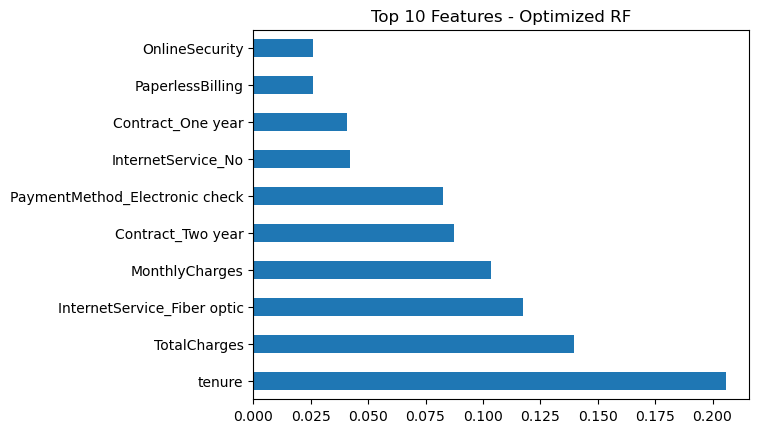

tenure                            0.205735
TotalCharges                      0.139732
InternetService_Fiber optic       0.117484
MonthlyCharges                    0.103340
Contract_Two year                 0.087189
PaymentMethod_Electronic check    0.082549
InternetService_No                0.041966
Contract_One year                 0.040729
PaperlessBilling                  0.025919
OnlineSecurity                    0.025811
dtype: float64


In [110]:
#feature importance
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.head(10).plot(kind="barh")
plt.title("Top 10 Features - Optimized RF")
plt.show()
print(importances.head(10))

Top drivers :tenure , TotalCharges and the least online security and PaperlessBilling with equal margin

In [111]:
pd.Series(baseline.coef_[0], index=X.columns).sort_values(key=abs,ascending=False).head(10)


Contract_Two year                -1.312039
tenure                           -1.231414
InternetService_No               -1.023828
InternetService_Fiber optic       1.020592
Contract_One year                -0.685113
TotalCharges                      0.497375
PaymentMethod_Electronic check    0.385017
OnlineSecurity                   -0.380143
PhoneService                     -0.377215
PaperlessBilling                  0.374956
dtype: float64

In [274]:
#Final generalization
print(f"Optimized RF CV ROC: {grid.best_score_:.4f}+/- {grid.cv_results_["std_test_score"][grid.best_index_]:.4f}")
print(f"Optimized RF Test ROC: {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]):.4f}")
print(f"Generalization Gap (CV vs Test):{abs(grid.best_score_ - roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])):.4f}")

Optimized RF CV ROC: 0.8463+/- 0.0121
Optimized RF Test ROC: 0.8466
Generalization Gap (CV vs Test):0.0003


Generalization evaluated by Train-Test Gap and CV. RF Optimized Gap reduced to Acc=0.024 and ROC= 0.045 vs Acc=0.126 and ROC=0.144
default. CV ROC 0.8463 vs Test ROC 0.8465 difference 0.0002 shows excellent generalization to unseen data

In [276]:
import joblib

In [277]:
joblib.dump(best_rf,"best_rf_churn_week4.pkl")

['best_rf_churn_week4.pkl']

Best Model = RF optimized: highest Test ROC=0.846591>Baseline=0.842272 with low gap (<0.05) and CV 0.8463

In [120]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [121]:
print("\nClassification Report:\n", classification_report(y_test, best_rf.predict(X_test)))
print("\nConfusion Matrix:\n" , confusion_matrix(y_test, best_rf.predict(X_test)))


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.68      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
 [[945  90]
 [187 187]]


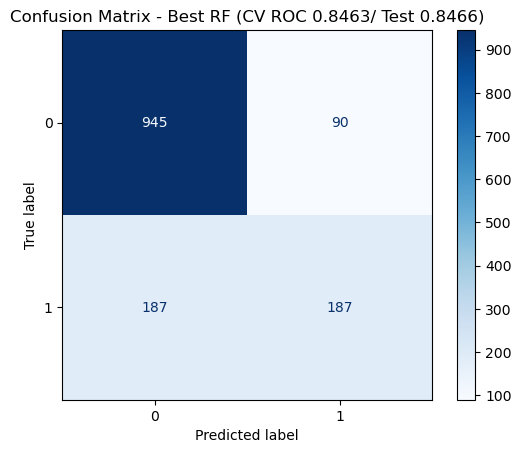

In [122]:
ConfusionMatrixDisplay.from_estimator(best_rf, X_test,y_test, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Best RF (CV ROC 0.8463/ Test 0.8466)")
plt.show()

TP = 945 , FN=187, TN=187 , TN=90